Test 3 : même chose que Test 2 mais j'ajoute 3 variables : 
-pnns_groups_1 — catégorie alimentaire large (~10 groupes : "sugary snacks", "beverages", "fruits and vegetables"...). Probablement le plus prometteur de la liste : le nutriscore est calculé différemment selon la catégorie de produit, donc cette info est structurellement très informative.
-nova_group (1 à 4, classification du degré de transformation — techniquement catégoriel ordonné mais souvent utilisé tel quel comme numérique)
-additives_n (nombre d'additifs, déjà numérique)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
%load_ext autoreload
%autoreload 2 

#pour pas avoir à reload à chaque fois qu'on mofifie une fonction dans un autre fichier

In [4]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g',
            'nova_group', 'additives_n', 'pnns_groups_1']  # nouvelles features

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,
    missing_threshold=50,
    features=mes_features,
)

print(preprocess_full["X_train"].shape)
print("Colonnes encodées :", preprocess_full["colonnes_encodees"])
print(list(preprocess_full["X_train"].columns))

(1101328, 20)
Colonnes encodées : ['pnns_groups_1']
['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'proteins_100g', 'fat_100g', 'carbohydrates_100g', 'nova_group', 'additives_n', 'pnns_groups_1_Alcoholic beverages', 'pnns_groups_1_Beverages', 'pnns_groups_1_Cereals and potatoes', 'pnns_groups_1_Composite foods', 'pnns_groups_1_Fat and sauces', 'pnns_groups_1_Fish Meat Eggs', 'pnns_groups_1_Fruits and vegetables', 'pnns_groups_1_Milk and dairy products', 'pnns_groups_1_Salty snacks', 'pnns_groups_1_Sugary snacks', 'pnns_groups_1_unknown']


In [6]:
from outliers import identify_impossible, apply_impossible_nan


X_train, y_train = preprocess_full["X_train"], preprocess_full["y_train"]
X_test,  y_test  = preprocess_full["X_test"],  preprocess_full["y_test"]
X_inconnu        = preprocess_full["X_inconnu"]

print("Avant nettoyage :")
print("Train :", X_train.shape, "| Test :", X_test.shape, "| Inconnu :", X_inconnu.shape)
print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

# Nettoyage des valeurs impossibles
X_train, y_train = apply_impossible_nan(X_train, y_train)
X_test,  y_test  = apply_impossible_nan(X_test, y_test)
X_inconnu        = apply_impossible_nan(X_inconnu)

print("\nAprès nettoyage :")
print("Train :", X_train.shape, "| Test :", X_test.shape, "| Inconnu :", X_inconnu.shape)

Avant nettoyage :
Train : (1101328, 20) | Test : (275333, 20) | Inconnu : (3114826, 20)
(1101328, 20)

Après nettoyage :
Train : (1101328, 20) | Test : (275333, 20) | Inconnu : (3114826, 20)


In [ ]:
##Randrom Forest

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

 
forestdefault = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
forestdefault.fit(X_train, y_train)
 
y_pred = forestdefault.predict(X_test)
 
print(classification_report(y_test, y_pred))
print(f"Accuracy test : {forestdefault.score(X_test, y_test):.4f}")

              precision    recall  f1-score   support

           a       0.72      0.82      0.77     40092
           b       0.68      0.67      0.68     31680
           c       0.79      0.70      0.75     57363
           d       0.80      0.75      0.78     69425
           e       0.77      0.84      0.80     76773

    accuracy                           0.77    275333
   macro avg       0.76      0.76      0.75    275333
weighted avg       0.77      0.77      0.76    275333

Accuracy test : 0.7655


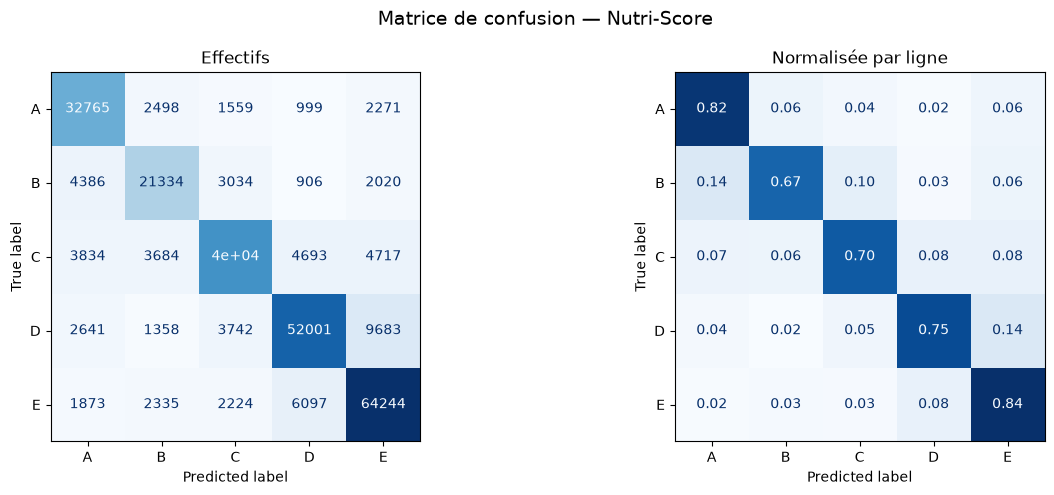

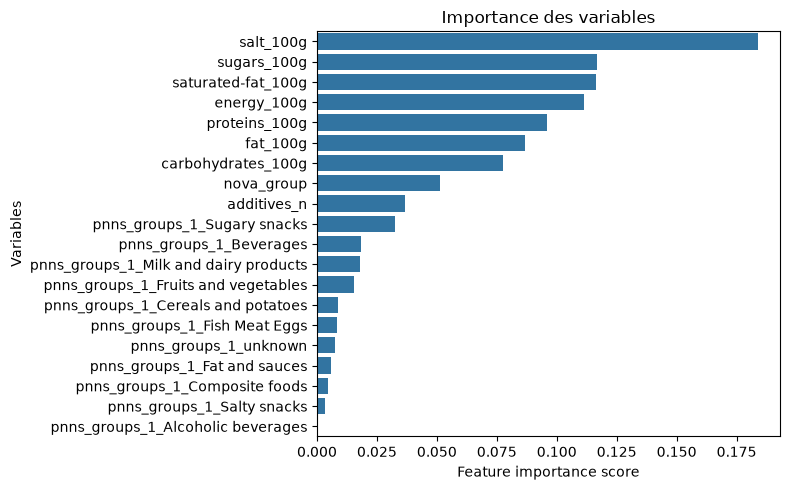

salt_100g                                0.183903
sugars_100g                              0.116693
saturated-fat_100g                       0.116565
energy_100g                              0.111228
proteins_100g                            0.095920
fat_100g                                 0.086939
carbohydrates_100g                       0.077666
nova_group                               0.051317
additives_n                              0.036834
pnns_groups_1_Sugary snacks              0.032466
pnns_groups_1_Beverages                  0.018395
pnns_groups_1_Milk and dairy products    0.018029
pnns_groups_1_Fruits and vegetables      0.015532
pnns_groups_1_Cereals and potatoes       0.008645
pnns_groups_1_Fish Meat Eggs             0.008503
pnns_groups_1_unknown                    0.007525
pnns_groups_1_Fat and sauces             0.005912
pnns_groups_1_Composite foods            0.004394
pnns_groups_1_Salty snacks               0.003446
pnns_groups_1_Alcoholic beverages        0.000086


In [12]:
# --- Matrice de confusion ---
labels = sorted(y_train.unique())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ConfusionMatrixDisplay.from_estimator(
    forestdefault, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Effectifs")
 
ConfusionMatrixDisplay.from_estimator(
    forestdefault, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", normalize="true", values_format=".2f",
    ax=axes[1], colorbar=False
)
axes[1].set_title("Normalisée par ligne")
 
fig.suptitle("Matrice de confusion — Nutri-Score", fontsize=14)
plt.tight_layout()
plt.show()

# --- Importance des variables ---
feature_scores = pd.Series(forestdefault.feature_importances_,
                           index=X_train.columns).sort_values(ascending=False)
 
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel("Feature importance score")
plt.ylabel("Variables")
plt.title("Importance des variables")
plt.tight_layout()
plt.show()
 
print(feature_scores)

Avec les 3 nouvelles variables, l'accruacy a légèrement diminué (moins d'overfit?) ainsi que la précision. Regardons la courbe

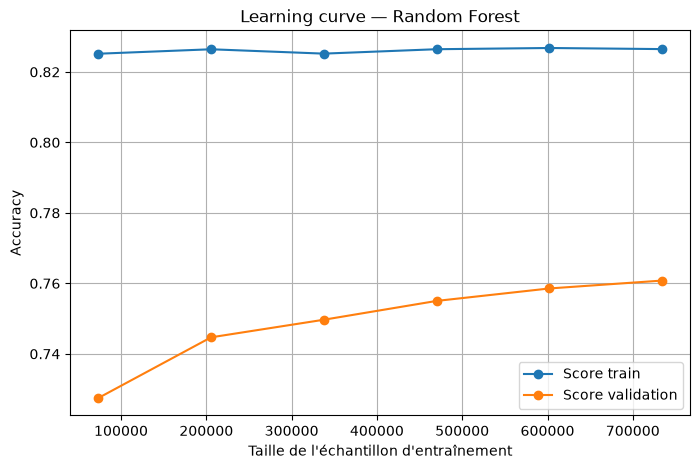

Écart train/validation final : 0.066


In [9]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")

train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),  # 10%, 28%, 46%, 64%, 82%, 100% du train
    cv=3,                # 3 folds suffisent, 5 double le temps de calcul
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Score train")
plt.plot(train_sizes, val_mean, "o-", label="Score validation")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title("Learning curve — Random Forest")
plt.legend()
plt.grid(True)
plt.show()
print(f"Écart train/validation final : {train_mean[-1] - val_mean[-1]:.3f}")

L'écart est plus faible que sans les 3 nouvelles features, ce qui est un bon signe. Cela signifie que le modèle généralise mieux sur les données de validation.